In [2]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_breast_cancer
from sklearn.linear_model import LogisticRegression

cancer = load_breast_cancer()

In [3]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

scaler = StandardScaler()
data_scaled = scaler.fit_transform(cancer.data)

X_train, X_test, y_train, y_test = train_test_split(data_scaled, cancer.target, test_size=0.3, random_state=42)

In [4]:
from sklearn.metrics import accuracy_score, roc_auc_score

lr_clf = LogisticRegression()
lr_clf.fit(X_train, y_train)
lr_pred = lr_clf.predict(X_test)
lr_pred_proba = lr_clf.predict_proba(X_test)[:,1]

print(accuracy_score(y_test, lr_pred), roc_auc_score(y_test, lr_pred_proba))

0.9824561403508771 0.9980893592004703


In [5]:
solvers = ['lbfgs', 'liblinear', 'newton-cg', 'sag', 'saga']

for solver in solvers:
    lr_clf = LogisticRegression(solver= solver, max_iter=600)
    lr_clf.fit(X_train, y_train)
    lr_pred = lr_clf.predict(X_test)
    lr_pred_proba = lr_clf.predict_proba(X_test)[:,1]

    print(solver)
    print(accuracy_score(y_test, lr_pred))
    print(roc_auc_score(y_test, lr_pred_proba))

lbfgs
0.9824561403508771
0.9980893592004703
liblinear
0.9824561403508771
0.9980893592004703
newton-cg
0.9824561403508771
0.9979423868312757
sag
0.9824561403508771
0.9980893592004703
saga
0.9824561403508771
0.9980893592004703


In [6]:
from sklearn.model_selection import GridSearchCV

params = {'solver':['liblinear', 'lbfgs'],
          'l1_ratio' : [0,1],
          'C': [0.01,0.1,1,5,10]}

lr_clf = LogisticRegression()
grid_clf = GridSearchCV(lr_clf, param_grid = params, scoring='accuracy', cv=3)

grid_clf.fit(data_scaled, cancer.target)
print(grid_clf.best_params_, grid_clf.best_score_)

{'C': 0.1, 'l1_ratio': 0, 'solver': 'liblinear'} 0.9789102385593614


c:\Users\KDS23\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\model_selection\_validation.py:489: FitFailedWarning: 
15 fits failed out of a total of 60.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
15 fits failed with the following error:
Traceback (most recent call last):
  File "c:\Users\KDS23\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\model_selection\_validation.py", line 851, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
    ~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\KDS23\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\base.py", line 1403, in wrapper
    return fit_method(estimator, *args, **kwargs)
  File "c:\Users\KDS23\AppDat

In [8]:
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import cross_val_score
from sklearn.ensemble import RandomForestRegressor
import pandas as pd
import numpy as np

housing = fetch_california_housing()
df = pd.DataFrame(housing.data, columns= housing.feature_names)

df['PRICE'] = housing.target

y_target = df['PRICE']
X_data = df.drop(['PRICE'], axis=1, inplace=False)

In [9]:
rf = RandomForestRegressor(random_state=42, 
                           n_estimators=1000, 
                           n_jobs= -1)

neg_mse_scores = cross_val_score(rf, X_data, y_target, 
                                 scoring= 'neg_mean_squared_error',
                                 cv=5)

rmse_scores = np.sqrt(-1 * neg_mse_scores)
avg_rmse = np.mean(rmse_scores)

print(neg_mse_scores)
print(rmse_scores)
print(avg_rmse)

[-0.51685719 -0.34439899 -0.36987608 -0.43571066 -0.46231712]
[0.7189278  0.58685517 0.60817438 0.66008383 0.67993906]
0.6507960481610622


In [10]:
def get_model_cv_prediction(model, X_data, y_target):
    neg_mse_scores = cross_val_score(model, X_data, y_target,
                                     scoring= 'neg_mean_squared_error',
                                     cv=5)

    rmse_scores = np.sqrt(-1 * neg_mse_scores)
    avg_rmse = np.mean(rmse_scores)
    print(model.__class__.__name__)
    print(avg_rmse)

In [11]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import GradientBoostingRegressor
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor

dt_reg = DecisionTreeRegressor(random_state=42, max_depth=4)
rf_reg = RandomForestRegressor(random_state=42, 
                               n_estimators=1000,
                               n_jobs=-1)
gb_reg = GradientBoostingRegressor(random_state=42, 
                                   n_estimators=1000)
xgb_reg = XGBRegressor(n_estimators = 1000)
lgb_reg = LGBMRegressor(n_estimators=1000)

models = [dt_reg, rf_reg, gb_reg, xgb_reg, lgb_reg]

for model in models:
    get_model_cv_prediction(model, X_data, y_target)

DecisionTreeRegressor
0.809181256232255
RandomForestRegressor
0.6507960481610622
GradientBoostingRegressor
0.6280374682398645
XGBRegressor
0.667288924956306
LGBMRegressor
0.6299695797309488


<Axes: xlabel='None', ylabel='None'>

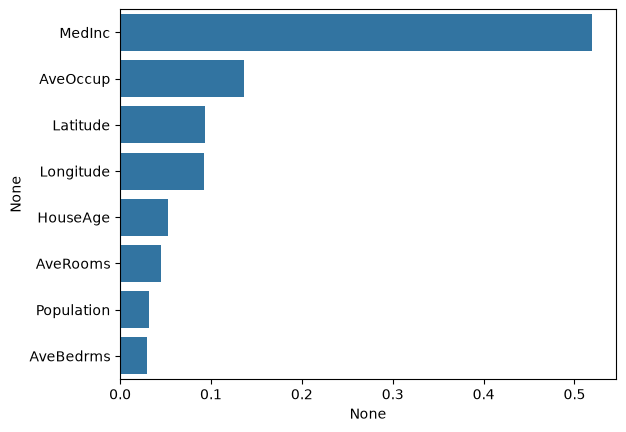

In [12]:
import seaborn as sns

rf_reg = RandomForestRegressor(n_estimators= 1000,
                               n_jobs= -1)

rf_reg.fit(X_data, y_target)

feature_series = pd.Series(data = rf_reg.feature_importances_,index=X_data.columns)
feature_series = feature_series.sort_values(ascending=False)
sns.barplot(x = feature_series, y= feature_series.index)

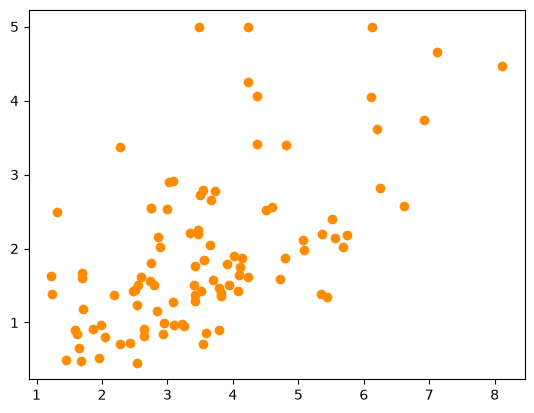

In [15]:
import matplotlib.pyplot as plt
df_sample = df[['MedInc', 'PRICE']]
df_sample = df_sample.sample(n=100, random_state=42)
plt.figure()
plt.scatter(df_sample.MedInc, df_sample.PRICE, c='darkorange')

In [17]:
import numpy as np
from sklearn.linear_model import LinearRegression

lr_reg = LinearRegression()
dt_reg2 = DecisionTreeRegressor(max_depth= 2)
dt_reg7 = DecisionTreeRegressor(max_depth= 7)

X_test = np.arange(1.0, 10.0, 0.09).reshape(-1,1)

X_feature = df_sample['MedInc'].values.reshape(-1,1)
y_target = df_sample['PRICE'].values.reshape(-1,1)

lr_reg.fit(X_feature, y_target)
dt_reg2.fit(X_feature, y_target)
dt_reg7.fit(X_feature, y_target)

pred_lr = lr_reg.predict(X_test)
pred_dt2 = dt_reg2.predict(X_test)
pred_dt7 = dt_reg7.predict(X_test)

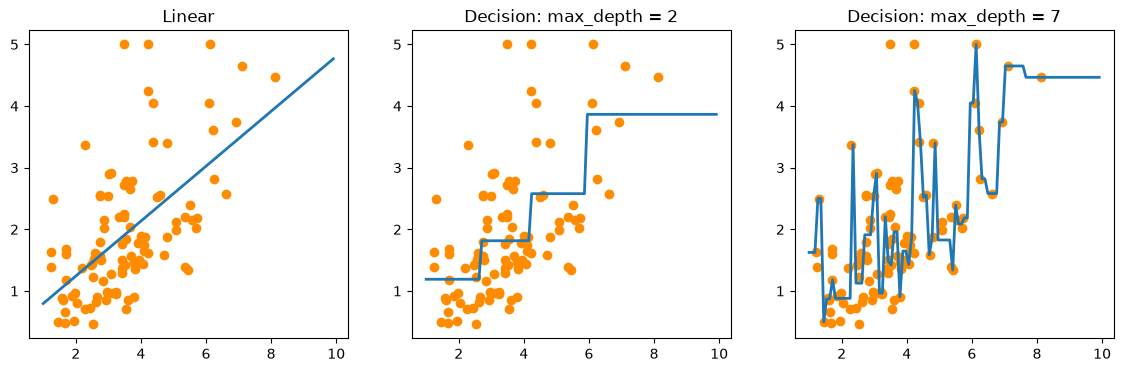

In [20]:
fig, (ax1,ax2,ax3) = plt.subplots(figsize=(14,4),  ncols=3)

ax1.set_title('Linear')
ax1.scatter(df_sample.MedInc, df_sample.PRICE, c = 'darkorange')
ax1.plot(X_test, pred_lr, label = 'linear', linewidth = 2)

ax2.set_title('Decision: max_depth = 2')
ax2.scatter(df_sample.MedInc, df_sample.PRICE, c = 'darkorange')
ax2.plot(X_test, pred_dt2, label = 'max_depth = 2', linewidth = 2)

ax3.set_title('Decision: max_depth = 7')
ax3.scatter(df_sample.MedInc, df_sample.PRICE, c = 'darkorange')
ax3.plot(X_test, pred_dt7, label = 'max_depth = 7', linewidth = 2)